In [1]:
import symlib
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import colormaps
import matplotlib.colors as mcolors
import scipy
from scipy import stats

**Trying to make a global plotting function to make any relevant plots, similar to MATLAB:**

In [40]:
## global plotting variables
colors = ["black", "tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]
avg_colors = [(0,0,0), (102/225, 0/255, 110/255), (7/255, 0/255, 110/255), (22/255, 112/255, 0/255), (163/255, 90/255, 2/255), (128/255, 3/255, 3/255)]

## global data location variables
base_dir = "C:/Users/steph/Symphony"
suite_list = ["MWest", "SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
#suite_list = ["MWest", "SymphonyLCluster"]
redshifts = [0]

In [41]:
## plotting function pseudocode:

# def plotter(plot_type, ncols, nrows, figsize, etc etc)
    # if plot_type == "SHMF":
        # x_data, y_data = SHMF_data[0], SHMF_data[1]
        ## plot the histogram
    # if plot_type == "MAH":
        # x_data, y_data = MAH_data[0], MAH_data[1]
        ## make the plot

## i could make smaller functions to read in the data for MAH and SHMF, then have plotter call those?

In [42]:
def MAH_data_read_in(base_dir, suite_list):

    test1 = []
    test2 = []
    
    for suite_index, suite_name in enumerate(suite_list):
        print(suite_index + 1, suite_name)
        n_hosts = symlib.n_hosts(suite_name)

        masses_suite = np.zeros(n_hosts, dtype = "object")

        for i_host in range(n_hosts):
            sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
            h, hist = symlib.read_subhalos(sim_dir)
            scale_factors = symlib.scale_factors(sim_dir)

            params = symlib.simulation_parameters(sim_dir)
            particle_mass = params["mp"]
        
            host_mass = np.array(h["mvir"][0])
            num_particles = host_mass / particle_mass
            mass_cut = 300 * particle_mass
        
            host_mass_masked = np.where(host_mass < mass_cut, np.nan, host_mass)    # replace all entries < 300 particle masses with np.nan
            #ax.plot(scale_factors, host_mass_masked, color = colors[index], lw = 0.75, alpha = 0.33)
            masses_suite[i_host] = host_mass[0:236]
    
        vstacked_masses = np.vstack(masses_suite)

        test1.append(scale_factors)
        test2.append(vstacked_masses)

    return test1, test2

In [43]:
data = MAH_data_read_in(base_dir, suite_list)

1 MWest
2 SymphonyLMC
3 SymphonyMilkyWay
4 SymphonyGroup
5 SymphonyLCluster
6 SymphonyCluster


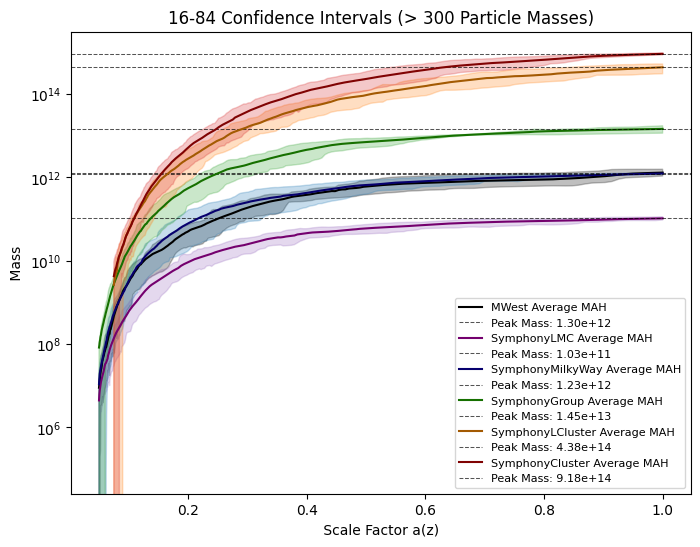

In [56]:
## this is the "plot" logic for the MAH plotting code

fig, ax = plt.subplots(figsize = (8,6))

scale_factors = data[0]
stacked_masses = data[1]

for arr_index, arr in enumerate(stacked_masses):
    avg_masses = np.mean(arr, axis = 0)
    percentile_16 = np.percentile(arr, 16, axis = 0)
    percentile_84 = np.percentile(arr, 84, axis = 0)
    
    ax.plot(scale_factors[arr_index], avg_masses, color = avg_colors[arr_index], label = f"{suite_list[arr_index]} Average MAH")
    ax.fill_between(scale_factors[arr_index], percentile_16, percentile_84, color = colors[arr_index], alpha = 0.25)
    ax.axhline(y = avg_masses[-1], color = "black", linestyle = '--', lw = 0.75, alpha = 0.67, label = f"Peak Mass: {(avg_masses[-1]):.2e}")
    
ax.set_yscale("log")
ax.set_xlabel(r" Scale Factor a(z) ", fontsize = 10)
ax.set_ylabel(r" Mass ", fontsize = 10)
#ax.set_ylim(1e2 * particle_mass, 1e8 * particle_mass)
#ax.set_ylim(5e6, 1e16)
ax.legend(loc = 'best', fontsize = 8)
ax.set_title(f"16-84 Confidence Intervals (> 300 Particle Masses)", loc = "center", fontsize = 12)
plt.show()